<a href="https://colab.research.google.com/github/RobertDS-45/Money_Remmitence_analysis/blob/main/Bot_Money_remmitence_analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import files
import pandas as pd

# Upload the file
uploaded = files.upload()

# Assuming the user uploads 'Money_Remittance_transactions_2025.csv'
# You can then read it into a pandas DataFrame
for fn in uploaded.keys():
    print(f'User uploaded file "{fn}"')
    df = pd.read_csv(fn)
    display(df.head())


Saving Money_Remittance_transactions_2025.csv to Money_Remittance_transactions_2025.csv
User uploaded file "Money_Remittance_transactions_2025.csv"


,INSTITUTIONCODE,REPORTINGDATE,DESCRIPTIONNO,COMPANY,INFLOW_VOLUME,INFLOW_VALUE,OUTFLOW_VOLUME,OUTLOW_VALUE
0,Bnk-001,1/31/2025,1,Western Union,"3,745","2,207,540,409",573,"273,899,340"
1,Bnk-001,1/31/2025,2,MoneyGram,"1,941","1,351,849,159",166,"116,292,545"
2,Bnk-001,1/31/2025,3,Travelex,273,"1,071,463,474",22,"108,098,083"
3,Bnk-001,1/31/2025,4,UBA Africash,169,"71,548,144",16,"8,833,937"
4,Bnk-001,1/31/2025,5,Coinstar,0,0,0,0


In [ ]:
df.tail()

,INSTITUTIONCODE,REPORTINGDATE,DESCRIPTIONNO,COMPANY,INFLOW_VOLUME,INFLOW_VALUE,OUTFLOW_VOLUME,OUTLOW_VALUE
5035,Bnk-042,12/31/2025,6,Express Money,0,0,0,0
5036,Bnk-042,12/31/2025,7,World Remit,0,0,0,0
5037,Bnk-042,12/31/2025,8,Tanzania Postal Services Inter state,0,0,0,0
5038,Bnk-042,12/31/2025,9,Diaspora Data through Swift,0,0,0,0
5039,Bnk-042,12/31/2025,10,Other Remitance company(s),0,0,0,0


In [ ]:
df.describe()

,DESCRIPTIONNO,OUTFLOW_VOLUME
count,5040.000000,5040.000000
mean,5.500000,11.724603
std,2.872566,57.637492
min,1.000000,0.000000
25%,3.000000,0.000000
50%,5.500000,0.000000
75%,8.000000,0.000000
max,10.000000,934.000000


In [ ]:
df.columns

Index(['INSTITUTIONCODE', 'REPORTINGDATE', 'DESCRIPTIONNO', 'COMPANY',
       'INFLOW_VOLUME', 'INFLOW_VALUE', 'OUTFLOW_VOLUME', 'OUTLOW_VALUE'],
      dtype='object')

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline
sns.set_theme(style='whitegrid')
plt.rcParams['figure.figsize']=[12,6]

In [ ]:
print("stage 1.1: Loading and cleaning raw data...")
df=pd.read_csv('Money_Remittance_transactions_2025.csv')
df.columns

stage 1.1: Loading and cleaning raw data...


Index(['INSTITUTIONCODE', 'REPORTINGDATE', 'DESCRIPTIONNO', 'COMPANY',
       'INFLOW_VOLUME', 'INFLOW_VALUE', 'OUTFLOW_VOLUME', 'OUTLOW_VALUE'],
      dtype='object')

In [ ]:
# fixing header typo
df =df.rename(columns={'OUTLOW_VALUE': 'OUTFLOW_VALUE'})

In [ ]:
# clean string formating
num_cols = ['INFLOW_VOLUME', 'INFLOW_VALUE', 'OUTFLOW_VOLUME', 'OUTFLOW_VALUE']
for col in num_cols:
  df[col]= df[col].astype(str).str.replace(',', '', regex=True)
  df[col] = pd.to_numeric(df[col],errors='coerce').fillna(0)

# standadize data format and parse reporting month
df['REPORTINGDATE'] = pd.to_datetime(df['REPORTINGDATE'],errors='coerce')
df['MONTH'] = df['REPORTINGDATE'].dt.month.fillna(0).astype(int)

# create a composite total turnover feature
df['TOTAL_VALUE'] = df['INFLOW_VOLUME'] + df['OUTFLOW_VALUE']
print(f"Data succefully cleaned. shape: {df.shape}")

Data succefully cleaned. shape: (5040, 10)



 Stage 1.2: Generating Visualization for analysis...


/tmp/ipykernel_3762/1478084774.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=monthly_market, x='MONTH',y='TOTAL_VALUE',palette='viridis', legend=False)


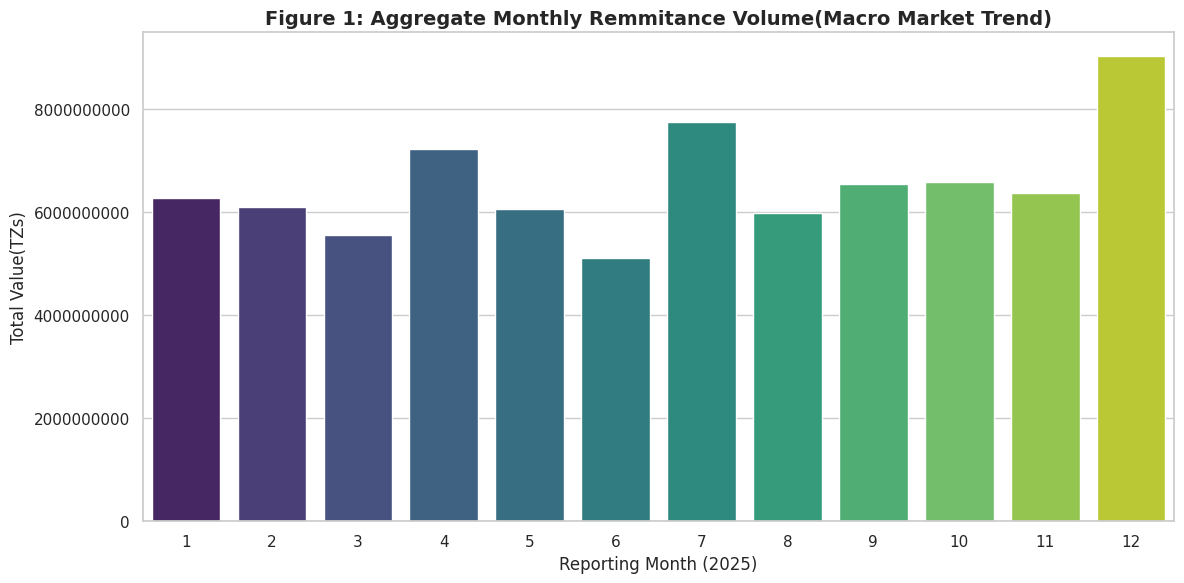

In [ ]:
# 1.2 VISUAL DATA EXPLORATION (EDA)
print("\n Stage 1.2: Generating Visualization for analysis...")
# plot A: Market seasonality chek (total Macro Value by Month)
monthly_market = df.groupby('MONTH')['TOTAL_VALUE'].sum().reset_index()

plt.figure()
sns.barplot(data=monthly_market, x='MONTH',y='TOTAL_VALUE',palette='viridis', legend=False)
plt.title('Figure 1: Aggregate Monthly Remmitance Volume(Macro Market Trend)',fontsize=14,fontweight='bold')
plt.xlabel('Reporting Month (2025)',fontsize=12)
plt.ylabel('Total Value(TZs)',fontsize=12)
plt.ticklabel_format(style='plain',axis='y')
plt.tight_layout()
plt.savefig('eda_market_seasonality.png',dpi=300)
plt.show()